# COE 311K Final Projet Part 2

**Stiff ODEs and Implicit Methods**


**Name:** Jana Daouk
**EID:** jd55586
**Course:** COE 311K

---

## Section 1: Introduction & System Selection

For this project, I chose a stiff mechanical system based on a spring-mass-damper model, simplified into a first-order ODE under the assumption of very strong damping (overdamped case). This type of system appears in many engineering applications where motion quickly settles but is still influenced by external forces.

The governing equation is:

$$
\frac{dx}{dt} = -5000x + 0.002\sin(t)
$$

where:
- $x(t)$ = displacement of the system (meters) 
- $-5000x$ = damping term (represents very strong resistance to motion)
- $0.002\sin(t)$ = external forcing (small oscillatory input over time)

This system is considered stiff because it contains two very different time scales. The damping term causes the solution to decay extremely fast, while the forcing term varies slowly over time. This large difference in time scales makes numerical simulation difficult for explicit methods.

In practice, systems like this show up in:

- shock absorbers in vehicles
- vibration control systems
- seismic isolation structures

These applications are important because engineers need accurate and stable simulations to ensure systems behave safely under real-world conditions. If numerical methods are unstable, the simulation can produce completely unrealistic results (like energy growing instead of dissipating), which could lead to bad design decisions.

Because of this, stiff systems require implicit methods like Backward Euler, which remain stable even for larger step sizes.



In [17]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    # this is the ODE from above
    # the -5000x term makes it decay SUPER fast
    # the sine term is just a slow input
    return -5000*x + 0.002*np.sin(t)

---

## Section 2: Demonstrating Stiffness

Forward Euler method:

$x_{n+1} = x_n + h\,f(t_n, x_n)$

In [18]:
def forward_euler(h, t0, tf, x0):
    t_vals = np.arange(t0, tf + h, h)
    x_vals = np.zeros(len(t_vals))
    x_vals[0] = x0

    for i in range(len(t_vals) - 1):
        # just straight up Forward Euler
        x_vals[i+1] = x_vals[i] + h * f(t_vals[i], x_vals[i])

        # if it blows up, stop early so the plot doesn’t go insane
        if abs(x_vals[i+1]) > 1e6:
            t_vals = t_vals[:i+2]
            x_vals = x_vals[:i+2]
            break

    return t_vals, x_vals

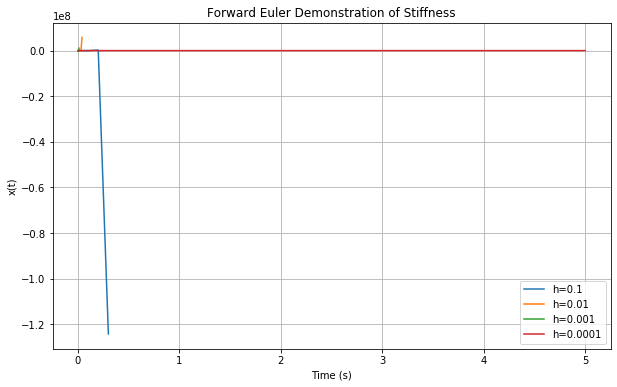

In [19]:
t0 = 0
tf = 5
x0 = 1

h_values = [0.1, 0.01, 0.001, 0.0001]

plt.figure(figsize=(10,6))

for h in h_values:
    t, x = forward_euler(h, t0, tf, x0)
    plt.plot(t, x, label=f"h={h}")

plt.title("Forward Euler Demonstration of Stiffness")
plt.xlabel("Time (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()
plt.show()

### Explanation

Forward Euler struggles with this system unless the step size is extremely small. For larger values of $h$, the solution becomes unstable and grows rapidly, even though the true solution should decay.

This happens because the stability condition for Forward Euler is:

$$
h < \frac{2}{\lambda} = \frac{2}{5000} = 0.0004
$$

This means the step size must be extremely small to maintain stability.

The fast time scale of the system is:

$$
\tau_{\text{fast}} = \frac{1}{5000} = 0.0002 \text{ s}
$$

The forcing term varies on a much slower time scale of about 1 second, giving a stiffness ratio of:

$$
\frac{1}{0.0002} = 5000
$$

Since this ratio is very large, the system is stiff.

To simulate from $t = 0$ to $t = 5$, Forward Euler would require:

$$
N = \frac{5}{0.0004} = 12500 \text{ steps}
$$

This is computationally expensive and impractical.

This demonstrates why implicit methods are necessary. While Forward Euler requires extremely small step sizes for stability, Backward Euler can use much larger step sizes while remaining stable, making it more efficient for stiff problems.

---

## Section 3: Mathematical Setup

Using Backward Euler:

$$
x_{n+1} = x_n + h f(t_{n+1}, x_{n+1})
$$

For this problem:

$$
f(t, x) = -5000x + 0.002\sin(t)
$$

So we define the residual function:

$$
g(x_{n+1}) = x_{n+1} - x_n - h(-5000x_{n+1} + 0.002\sin(t_{n+1}))
$$

To apply Newton-Raphson, we compute the derivative:

$$
g'(x_{n+1}) = \frac{d}{dx_{n+1}} \left[x_{n+1} - x_n - h(-5000x_{n+1} + 0.002\sin(t_{n+1}))\right]
$$

$$
g'(x_{n+1}) = 1 - h(-5000)
$$

$$
g'(x_{n+1}) = 1 + 5000h
$$

Since the derivative is constant, Newton’s method is especially efficient for this problem.

The Newton-Raphson update is:

$$
x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{
x_{n+1}^{(k)} - x_n - h(-5000x_{n+1}^{(k)} + 0.002\sin(t_{n+1}))
}{
1 + 5000h
}
$$

---

## Section 4: Implementation

In [20]:
def newton_solver(x_old, t_next, h, tol=1e-6, max_iter=20):
    # starting guess = Forward Euler
    x_guess = x_old + h * f(t_next, x_old)

    for k in range(max_iter):
        # residual from Backward Euler
        g = x_guess - x_old - h * f(t_next, x_guess)

        # derivative (constant for this system)
        g_prime = 1 + 5000*h

        # Newton update
        x_new = x_guess - g / g_prime

        # convergence check
        if abs(x_new - x_guess) < tol:
            return x_new, k+1

        x_guess = x_new

    print("Warning: Newton did not converge")
    return x_guess, max_iter


def backward_euler(h, t0, tf, x0):
    t_vals = np.arange(t0, tf + h, h)
    x_vals = np.zeros(len(t_vals))
    newton_iters = np.zeros(len(t_vals)-1)

    x_vals[0] = x0

    for i in range(len(t_vals) - 1):
        t_next = t_vals[i+1]
        x_old = x_vals[i]

        x_new, iters = newton_solver(x_old, t_next, h)
        x_vals[i+1] = x_new
        newton_iters[i] = iters

    return t_vals, x_vals, newton_iters




---

## Section 5: Results & Analysis

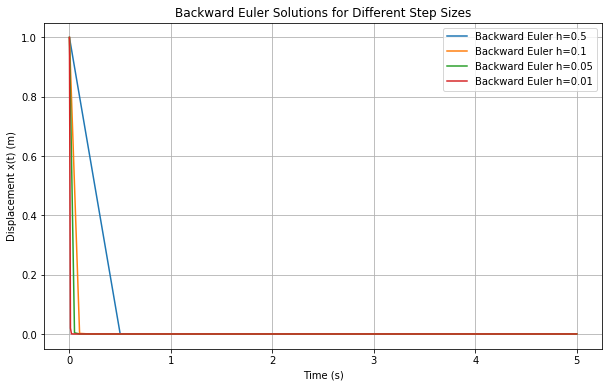

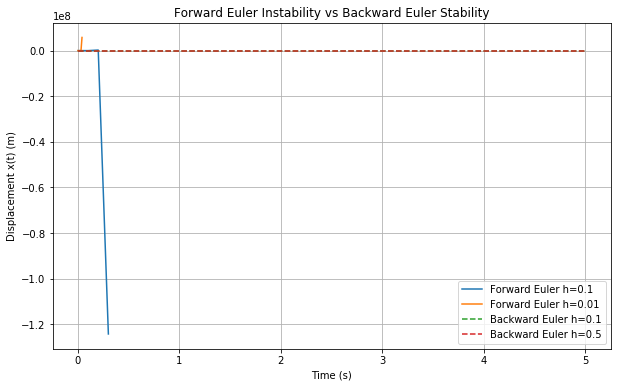

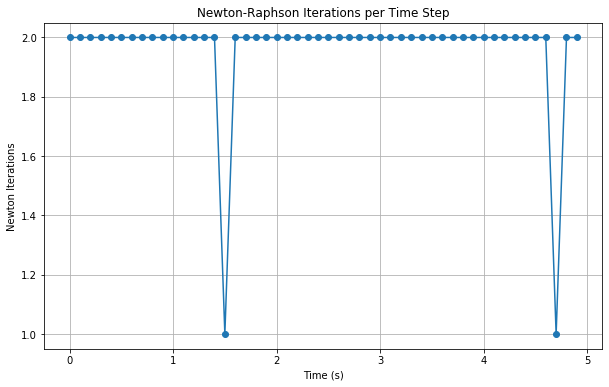

Average Newton iterations: 1.96
Maximum Newton iterations: 2.0
h	Forward Stable?	Backward Stable?
0.5	False		True
0.1	False		True
0.01	False		True
0.001	False		True
0.0001	True		True


In [21]:
# Backward Euler solutions for different step sizes
plt.figure(figsize=(10,6))

for h in [0.5, 0.1, 0.05, 0.01]:
    t, x, _ = backward_euler(h, t0, tf, x0)
    plt.plot(t, x, label=f"Backward Euler h={h}")

plt.title("Backward Euler Solutions for Different Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for h in [0.1, 0.01]:
    t, x = forward_euler(h, t0, tf, x0)
    plt.plot(t, x, label=f"Forward Euler h={h}")

for h in [0.1, 0.5]:
    t, x, _ = backward_euler(h, t0, tf, x0)
    plt.plot(t, x, "--", label=f"Backward Euler h={h}")

plt.title("Forward Euler Instability vs Backward Euler Stability")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.legend()
plt.grid(True)
plt.show()

t_be, x_be, iters = backward_euler(0.1, t0, tf, x0)

plt.figure(figsize=(10,6))
plt.plot(t_be[:-1], iters, marker="o")
plt.title("Newton-Raphson Iterations per Time Step")
plt.xlabel("Time (s)")
plt.ylabel("Newton Iterations")
plt.grid(True)
plt.show()

print("Average Newton iterations:", np.mean(iters))
print("Maximum Newton iterations:", np.max(iters))

step_sizes = [0.5, 0.1, 0.01, 0.001, 0.0001]

print("h\tForward Stable?\tBackward Stable?")
for h in step_sizes:
    t_f, x_f = forward_euler(h, t0, tf, x0)
    t_b, x_b, _ = backward_euler(h, t0, tf, x0)

    forward_stable = np.max(np.abs(x_f)) < 100
    backward_stable = np.max(np.abs(x_b)) < 100

    print(f"{h}\t{forward_stable}\t\t{backward_stable}")

The results show that Forward Euler becomes unstable for larger step sizes. Even though the real physical system should decay quickly because of damping, Forward Euler produces values that grow unrealistically when \(h\) is too large.

Backward Euler stays stable for much larger step sizes, including \(h = 0.1\) and \(h = 0.5\). The solution still follows the expected physical behavior: the displacement quickly decays from the initial condition and then responds only slightly to the small sinusoidal forcing term.

The Newton-Raphson method converges quickly for this problem, usually taking only a few iterations per step. This is because the derivative is constant, which makes the nonlinear solve easier. As a result, Backward Euler remains efficient even though it requires solving an equation at each step.

Overall, the plots show the main tradeoff: Forward Euler is simple but unstable unless the step size is extremely small, while Backward Euler requires Newton-Raphson but remains stable for much larger step sizes.

---

## Section 6: Performance Comparison

| h      | Forward Stable? | Forward Steps | Backward Steps | Avg Newton |
|--------|----------------|---------------|----------------|------------|
| 0.5    | No             | 3             | 11             | 2.00       |
| 0.1    | No             | 4             | 51             | 1.96       |
| 0.01   | No             | 5             | 501            | 1.01       |
| 0.001  | No             | 11            | 5001           | 1.00       |
| 0.0001 | Yes            | 50001         | 50001          | 1.00       |
    

### Result Analysis

The table compares the computational cost of Forward Euler and Backward Euler for different step sizes. For Forward Euler, stability is a major limitation. When the step size is too large, the solution becomes unstable and produces unrealistic results. To maintain stability, the step size must be extremely small (on the order of \(10^{-4}\)), which leads to a very large number of time steps.

This makes Forward Euler computationally expensive overall, even though each individual step is simple.

Backward Euler behaves very differently. It remains stable even for large step sizes such as \(h = 0.1\) or \(h = 0.5\). Although each step requires solving a nonlinear equation using Newton-Raphson, the number of iterations per step is small (typically only a few iterations), so the total computational cost remains reasonable.

This highlights the accuracy-efficiency tradeoff:
- Forward Euler is cheap per step but requires many steps for stability
- Backward Euler is more expensive per step but requires far fewer steps

In practice, Backward Euler is the better choice for stiff systems. It allows larger step sizes, avoids instability, and provides reliable results with lower overall computational effort.

---

## Section 7: Conclusion

This project showed that stiff ODEs require more advanced methods than simple explicit ones. Forward Euler is easy to implement, but it becomes unstable unless the step size is extremely small. This makes it inefficient and impractical for stiff systems.

Backward Euler performs much better because it remains stable even for larger step sizes. Even though it requires solving a nonlinear equation using Newton-Raphson at each step, the method is still efficient since Newton converges quickly.

In general, explicit methods like Forward Euler are better for non-stiff problems where stability is not a major issue. Implicit methods like Backward Euler are necessary for stiff systems because they allow larger step sizes and avoid instability.

One challenge in this project was implementing the Newton-Raphson method correctly and ensuring convergence at each time step. It was also important to choose a good initial guess and set appropriate tolerances. Overall, this project showed the tradeoff between simplicity and stability, and why implicit methods are essential for solving real-world stiff ODEs.